# Классификация изображений с помощью предварительно обученной нейронной сети VGG16

Чтобы запускать и редактировать код, сохраните копию этого ноутбука себе (Файл -> Создать копию на Диске). Свою копию вы сможете изменять и запускать.

Учебный курс "[Программирование глубоких нейронных сетей на Python](https://openedu.ru/course/urfu/PYDNN/)".

<a target="_blank" href="https://colab.research.google.com/github/sozykin/dlpython_course/blob/master/03_pretrained_networks/pytorch/vgg16_pretrained.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Подготовка к работе


In [1]:
from torchvision.io import read_image
from torchvision.models import vgg16, VGG16_Weights
import matplotlib.pyplot as plt
%matplotlib inline


## Загружаем предварительно обученную модель


Создаем модель с архитектурой VGG16 и загружаем веса, обученные на наборе данных ImageNet


In [2]:
# Веса, обученные на наборе данных ImageNet
weights = VGG16_Weights.IMAGENET1K_V1
# Создаем модель с предварительно обученными весами
model = vgg16(weights=weights)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/kirilman/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|████████████████████████████████████████| 528M/528M [00:48<00:00, 11.3MB/s]


Переключаем модель в режим распознавания


In [3]:
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Информация о модели


In [4]:
# Количество параметров модели
total_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров модели VGG16: {total_params:,}")


Всего параметров модели VGG16: 138,357,544


In [5]:
# Выводим описание слоев модели (аналог model.summary() из Keras)
print(model)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## Готовим инструменты предварительной обработки изображения


Каждая предварительно обученная нейронная сеть требует своей предварительной обработки.


In [6]:
preprocess = weights.transforms()


In [7]:
preprocess


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

## Загружаем изображение


Путь к изображению


In [8]:
# Изображение ship.jpg находится в родительской папке
img = read_image("../ship.jpg")


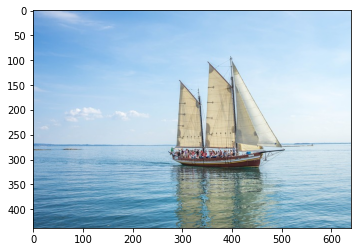

In [9]:
plt.imshow(img.permute(1, 2, 0))
plt.show()


## Выполняем предварительную обработку изображения


In [10]:
img


tensor([[[133, 134, 135,  ..., 189, 189, 189],
         [131, 131, 132,  ..., 189, 189, 189],
         [126, 127, 128,  ..., 189, 189, 189],
         ...,
         [ 44,  40,  36,  ...,  95,  97,  94],
         [ 60,  56,  54,  ...,  76,  81,  85],
         [ 57,  54,  51,  ..., 109, 110, 115]],

        [[171, 172, 173,  ..., 220, 220, 220],
         [169, 169, 170,  ..., 220, 220, 220],
         [166, 167, 168,  ..., 220, 220, 220],
         ...,
         [ 97,  93,  89,  ..., 150, 152, 151],
         [113, 109, 107,  ..., 133, 138, 144],
         [110, 107, 104,  ..., 166, 169, 174]],

        [[220, 221, 222,  ..., 248, 248, 248],
         [218, 218, 219,  ..., 248, 248, 248],
         [217, 218, 217,  ..., 248, 248, 248],
         ...,
         [129, 125, 121,  ..., 180, 182, 180],
         [147, 143, 141,  ..., 163, 168, 174],
         [144, 141, 138,  ..., 196, 199, 204]]], dtype=torch.uint8)

In [11]:
batch = preprocess(img).unsqueeze(0)


/home/kirilman/.local/lib/python3.8/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


In [12]:
batch.shape


torch.Size([1, 3, 224, 224])

## Выполняем классификацию изображения


Выполняем распознавание.

Перед подачей изображения в модель вычисляем вероятности классов с помощью функции softmax.


In [13]:
# Выход модели - логиты (значения до функции активации)
logits = model(batch)

# Преобразуем логиты в вероятности классов
probabilities = logits.squeeze(0).softmax(0)


In [14]:
# Число классов в наборе данных ImageNet
len(probabilities)


1000

In [15]:
# Сумма всех вероятностей равна 1
probabilities.sum()


tensor(1., grad_fn=<SumBackward0>)

Результаты распознавания — три наиболее вероятных класса объекта


In [16]:
results = probabilities.topk(3)
for prob, idx in zip(results.values, results.indices):
    print(f"{weights.meta['categories'][idx]}: {100 * prob.item():.1f}%")


schooner: 88.6%
yawl: 10.8%
trimaran: 0.3%


Выбираем класс с максимальной вероятностью


In [17]:
class_id = probabilities.argmax().item()


In [18]:
class_id


780

Получаем название класса


In [19]:
category_name = weights.meta["categories"][class_id]


In [20]:
category_name


'schooner'

Определяем вероятность принадлежности объекта данному классу


In [21]:
score = probabilities[class_id].item()


In [22]:
score


0.8862967491149902

Печатаем результаты распознавания


In [23]:
print(f"{category_name}: {100 * score:.1f}%")


schooner: 88.6%
